<a href="https://colab.research.google.com/github/Trondster/CS4140//blob/main/train/drone-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install "tensorflow==2.19.0" tf-keras tensorflow-model-optimization ai-edge-litert -q

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import random

import tensorflow as tf
import tf_keras as keras
from tf_keras import layers
import tensorflow_model_optimization as tfmot
from ai_edge_litert import interpreter as litert

print("TensorFlow:", tf.__version__)
print("Keras (legacy):", keras.__version__)

TensorFlow: 2.19.0
Keras (legacy): 2.19.0


# Extract zip

In [3]:
import os
import zipfile
import glob

from google.colab import drive
drive.mount('/content/drive')

DATASET_TO_USE = '2x2'

InputWidth = 80
InputHeight = 60

zip_file_path = 'drive/MyDrive/Embedded AI/dataset.zip'

# Define the root directory where the selected folders will be extracted.
extract_root_path = '.'

# Ensure the top-level 'dataset' folder exists within the extract_root_path
os.makedirs(os.path.join(extract_root_path, 'dataset'), exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        all_members = zip_ref.namelist()

        # Define the prefixes for the subfolders you want to extract
        target_prefixes = [f'dataset/{DATASET_TO_USE}/', 'dataset/labels/', 'dataset/ignored/']

        destination_folders = [f'dataset/{DATASET_TO_USE}/clear/', f'dataset/{DATASET_TO_USE}/drone/', 'dataset/labels/', 'dataset/ignored/']
        for destination in destination_folders:
            deleted = 0
            destination_path = os.path.join(extract_root_path, destination, '*')
            print(f"Destination Path '{destination_path}'.")
            files = glob.glob(destination_path)
            for f in files:
                if os.path.isfile(f):
                    os.remove(f)
                    deleted = deleted + 1
            print(f"Deleted {deleted} files from '{destination_path}'.")

        members_to_extract = []
        for member in all_members:
            for prefix in target_prefixes:
                if member.startswith(prefix) or member == prefix.rstrip('/'): # Include the directory itself
                    members_to_extract.append(member)
                    break

        print(f"Extracting {len(members_to_extract)} selected items from '{zip_file_path}'...")

        # Extract only the selected members
        for member in members_to_extract:
            zip_ref.extract(member, path=extract_root_path)

    print(f"Successfully extracted selected subfolders to '{extract_root_path}'")

    # List the contents of the target 'dataset' folder to verify
    target_list_path = os.path.join(extract_root_path, 'dataset')
    print(f"Contents of '{target_list_path}':")
    for root, dirs, files in os.walk(target_list_path):
        level = root.replace(target_list_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')

except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found. Please check the path.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Mounted at /content/drive
Destination Path './dataset/2x2/clear/*'.
Deleted 0 files from './dataset/2x2/clear/*'.
Destination Path './dataset/2x2/drone/*'.
Deleted 0 files from './dataset/2x2/drone/*'.
Destination Path './dataset/labels/*'.
Deleted 0 files from './dataset/labels/*'.
Destination Path './dataset/ignored/*'.
Deleted 0 files from './dataset/ignored/*'.
Extracting 23353 selected items from 'drive/MyDrive/Embedded AI/dataset.zip'...
Successfully extracted selected subfolders to '.'
Contents of './dataset':
dataset/
    2x2/
        clear/
        drone/
    labels/
    ignored/


In [4]:
import glob

# Define the paths to your image folders
drone_path = f'dataset/{DATASET_TO_USE}/drone'
clear_path = f'dataset/{DATASET_TO_USE}/clear'

# Get all image file paths from both folders
drone_images = glob.glob(os.path.join(drone_path, '*.png'))
clear_images = glob.glob(os.path.join(clear_path, '*.png'))

print(f"Found {len(drone_images)} drone images.")
print(f"Found {len(clear_images)} clear images.")

all_images = drone_images + clear_images
random.shuffle(all_images)

print(f"Total of {len(all_images)} images for training.")

Found 8136 drone images.
Found 7239 clear images.
Total of 15375 images for training.


The image filenames follow a pattern: `ID_type_frame.png` (e.g., `4407882_drone_current_frame.png`). For each unique `ID`, there should be a `_current_frame.png` and a `_diff_frame.png` image, and a corresponding `ID.txt` file in the `dataset/labels` folder. This `ID.txt` file contains the ground truth label (0 for clear, 1 for drone) and bounding box information.

We will now process all image paths to:
1.  Identify pairs of `current_frame` and `diff_frame` images based on their unique ID.
2.  Locate and read the corresponding `ID.txt` label file.
3.  Extract the label (first value in the `.txt` file) and bounding box data.
4.  Create a list `X` where each element is a tuple `(path_to_current_frame, path_to_diff_frame)`.
5.  Create a list `y` where each element is the integer label for the corresponding image pair.

In [5]:
import os
import glob
import random

# Combine all image paths from drone and clear categories
all_image_paths = drone_images + clear_images

# Dictionary to store image pairs and their label file path
image_pairs_data = {}

for img_path in all_image_paths:
    # Extract filename without extension
    basename = os.path.basename(img_path)
    filename_without_ext = os.path.splitext(basename)[0]

    # Extract unique ID and frame type
    # Example: '4407882_drone_current_frame' -> ID '4407882', frame_type 'current_frame'
    parts = filename_without_ext.split('_')
    image_id = parts[0]
    frame_type = '_'.join(parts[-2:]) # 'current_frame' or 'diff_frame'

    if image_id not in image_pairs_data:
        image_pairs_data[image_id] = {
            'current_frame': None,
            'diff_frame': None,
            'label_bbox': None # To store the (label, bbox) tuple
        }

    if 'current_frame' in frame_type:
        image_pairs_data[image_id]['current_frame'] = img_path
    elif 'diff_frame' in frame_type:
        image_pairs_data[image_id]['diff_frame'] = img_path

# Now, go through the image_pairs_data to find complete pairs and read labels
X_paired = [] # List of (current_frame_path, diff_frame_path)
y_labels_and_bboxes = [] # List of (integer label, bounding box data) tuples

label_dir = 'dataset/labels' # Directory where label .txt files are located

ignore_dir = 'dataset/ignored'

ignored = 0
for image_id, data in image_pairs_data.items():
    current_frame_path = data.get('current_frame')
    diff_frame_path = data.get('diff_frame')

    # Only process if both current and diff frames are found for this ID
    if current_frame_path and diff_frame_path:
        label_file_path = os.path.join(label_dir, f"{image_id}.txt")

        ignore_path = os.path.join(ignore_dir, f"{image_id}_ignored")

        if os.path.exists(ignore_path):
            print(f"Ignoring ID {image_id} at {ignore_path}")
            ignored = ignored + 1
        elif os.path.exists(label_file_path):
            try:
                with open(label_file_path, 'r') as f:
                    # Assuming the format in .txt is: label_id bbox_x bbox_y bbox_width bbox_height
                    line = f.readline().strip()
                    parts = line.split()
                    if parts:
                        label = int(parts[0]) # The first value is the class label (0 or 1)
                        # If no bounding box is present (e.g., for clear images where bbox is not relevant or missing),
                        # default to [0.0, 0.0, 0.0, 0.0] for consistency in tuple structure.
                        bbox = [float(p) for p in parts[1:]] if len(parts) > 1 else [0.0, 0.0, 0.0, 0.0]

                        X_paired.append((current_frame_path, diff_frame_path))
                        y_labels_and_bboxes.append((label, bbox))
            except Exception as e:
                print(f"Error reading label file {label_file_path}: {e}")
        else:
            print(f"Warning: Label file not found for ID {image_id} at {label_file_path}")

# Shuffle the paired data and labels/bboxes together to maintain correspondence
combined_data = list(zip(X_paired, y_labels_and_bboxes))
random.shuffle(combined_data)

# Unpack combined_data. X will be a list of (current_frame_path, diff_frame_path) tuples.
# y_combined will be a list of (label, bbox) tuples.
X, y_combined = zip(*combined_data)
X = list(X)
y_combined = list(y_combined) # This is the list of (label, bbox) tuples

# Separate y_combined into classification labels and bounding box coordinates for model training
y_classification = [item[0] for item in y_combined]
y_bounding_box = [item[1] for item in y_combined]

print(f"Found {len(X)} complete image pairs with labels and bounding boxes.")
print(f"Ignored {ignored} image pairs.")
print(f"First 5 X (image pairs): {X[:5]}")
print(f"First 5 y_combined (labels and bboxes): {y_combined[:5]}")
print(f"First 5 y_classification (labels only): {y_classification[:5]}")
print(f"First 5 y_bounding_box (bboxes only): {y_bounding_box[:5]}")


Ignoring ID 4380091 at dataset/ignored/4380091_ignored
Ignoring ID 714435 at dataset/ignored/714435_ignored
Ignoring ID 168372592363 at dataset/ignored/168372592363_ignored
Ignoring ID 2681346 at dataset/ignored/2681346_ignored
Ignoring ID 103038 at dataset/ignored/103038_ignored
Ignoring ID 1189629 at dataset/ignored/1189629_ignored
Ignoring ID 168372633416 at dataset/ignored/168372633416_ignored
Ignoring ID 7027956038 at dataset/ignored/7027956038_ignored
Ignoring ID 1171169 at dataset/ignored/1171169_ignored
Ignoring ID 1951916 at dataset/ignored/1951916_ignored
Ignoring ID 445654 at dataset/ignored/445654_ignored
Ignoring ID 1015837 at dataset/ignored/1015837_ignored
Ignoring ID 14030171554 at dataset/ignored/14030171554_ignored
Ignoring ID 118588348501 at dataset/ignored/118588348501_ignored
Ignoring ID 540669 at dataset/ignored/540669_ignored
Ignoring ID 645138 at dataset/ignored/645138_ignored
Ignoring ID 4795954 at dataset/ignored/4795954_ignored
Ignoring ID 118588194018 at dat

### Data Augmentation: Horizontal Flipping

To increase the dataset size and improve model generalization, we will perform data augmentation by horizontally flipping each image pair (current_frame and diff_frame) and adjust the bounding box coordinates accordingly. For a bounding box defined as `[x_center, y_center, width, height]`, the `x_center` will be transformed to `1 - x_center` after a horizontal flip, while other coordinates remain unchanged.

In [6]:
import os
from PIL import Image

# DATASET_TO_USE, InputWidth, InputHeight are already defined globally

def augment_data_horizontal_flip(X_original, y_combined_original, output_dir_suffix="_flipped"):
    X_augmented = list(X_original) # Start with original data
    y_combined_augmented = list(y_combined_original) # Start with original data

    # Create a base directory for flipped images if it doesn't exist
    base_output_dir = 'dataset' + output_dir_suffix
    os.makedirs(base_output_dir, exist_ok=True)

    # Create subdirectories for the specific DATASET_TO_USE and labels
    for category in ['drone', 'clear']:
        os.makedirs(os.path.join(base_output_dir, DATASET_TO_USE, category), exist_ok=True)

    print(f"Augmenting dataset by horizontal flipping...")
    for i, (current_frame_path, diff_frame_path) in enumerate(X_original):
        label, bbox = y_combined_original[i]

        # Determine the relative path for saving flipped images
        # e.g., 'dataset/2x2/drone/ID_frame.png' -> '2x2/drone/ID_frame.png'
        relative_current_path = os.path.relpath(current_frame_path, 'dataset')
        relative_diff_path = os.path.relpath(diff_frame_path, 'dataset')

        flipped_current_frame_path = os.path.join(base_output_dir, relative_current_path)
        flipped_diff_frame_path = os.path.join(base_output_dir, relative_diff_path)

        # Load, flip, and save current_frame image
        img_current = Image.open(current_frame_path).transpose(Image.FLIP_LEFT_RIGHT)
        img_current.save(flipped_current_frame_path)

        # Load, flip, and save diff_frame image
        img_diff = Image.open(diff_frame_path).transpose(Image.FLIP_LEFT_RIGHT)
        img_diff.save(flipped_diff_frame_path)

        # Adjust bounding box coordinates for horizontal flip
        # Bbox format: [x_center, y_center, box_width, box_height]
        # For horizontal flip, only x_center changes: new_x_center = 1.0 - old_x_center
        flipped_bbox = list(bbox) # Create a mutable copy
        if label == 1 and len(bbox) == 4 and any(b > 0 for b in bbox): # Only flip if it's a drone and bbox is valid
            flipped_bbox[0] = 1.0 - bbox[0] # Adjust x_center

        # Add the flipped data to the augmented lists
        X_augmented.append((flipped_current_frame_path, flipped_diff_frame_path))
        y_combined_augmented.append((label, flipped_bbox))

    print(f"Original dataset size: {len(X_original)}")
    print(f"Augmented dataset size (original + flipped): {len(X_augmented)}")
    return X_augmented, y_combined_augmented

# Apply augmentation and update the data variables
X, y_combined = augment_data_horizontal_flip(X, y_combined)

# Re-separate y_combined into classification labels and bounding box coordinates for consistency
y_classification = [item[0] for item in y_combined]
y_bounding_box = [item[1] for item in y_combined]

print(f"Total data points after augmentation: {len(X)}")
print(f"First 5 X (image pairs) after augmentation: {X[:5]}")
print(f"First 5 y_combined (labels and bboxes) after augmentation: {y_combined[:5]}")

Augmenting dataset by horizontal flipping...
Original dataset size: 7379
Augmented dataset size (original + flipped): 14758
Total data points after augmentation: 14758
First 5 X (image pairs) after augmentation: [('dataset/2x2/drone/3203644_drone_current_frame.png', 'dataset/2x2/drone/3203644_drone_diff_frame.png'), ('dataset/2x2/drone/3013840_drone_current_frame.png', 'dataset/2x2/drone/3013840_drone_diff_frame.png'), ('dataset/2x2/drone/4937728_drone_current_frame.png', 'dataset/2x2/drone/4937728_drone_diff_frame.png'), ('dataset/2x2/clear/118590806438_clear_current_frame.png', 'dataset/2x2/clear/118590806438_clear_diff_frame.png'), ('dataset/2x2/clear/118590787110_clear_current_frame.png', 'dataset/2x2/clear/118590787110_clear_diff_frame.png')]
First 5 y_combined (labels and bboxes) after augmentation: [(1, [0.689063, 0.51525, 0.265625, 0.1125]), (1, [0.741667, 0.75791, 0.3875, 0.119444]), (1, [0.44375, 0.560917, 0.45, 0.179167]), (0, [0.0, 0.0, 0.0, 0.0]), (0, [0.0, 0.0, 0.0, 0.0])

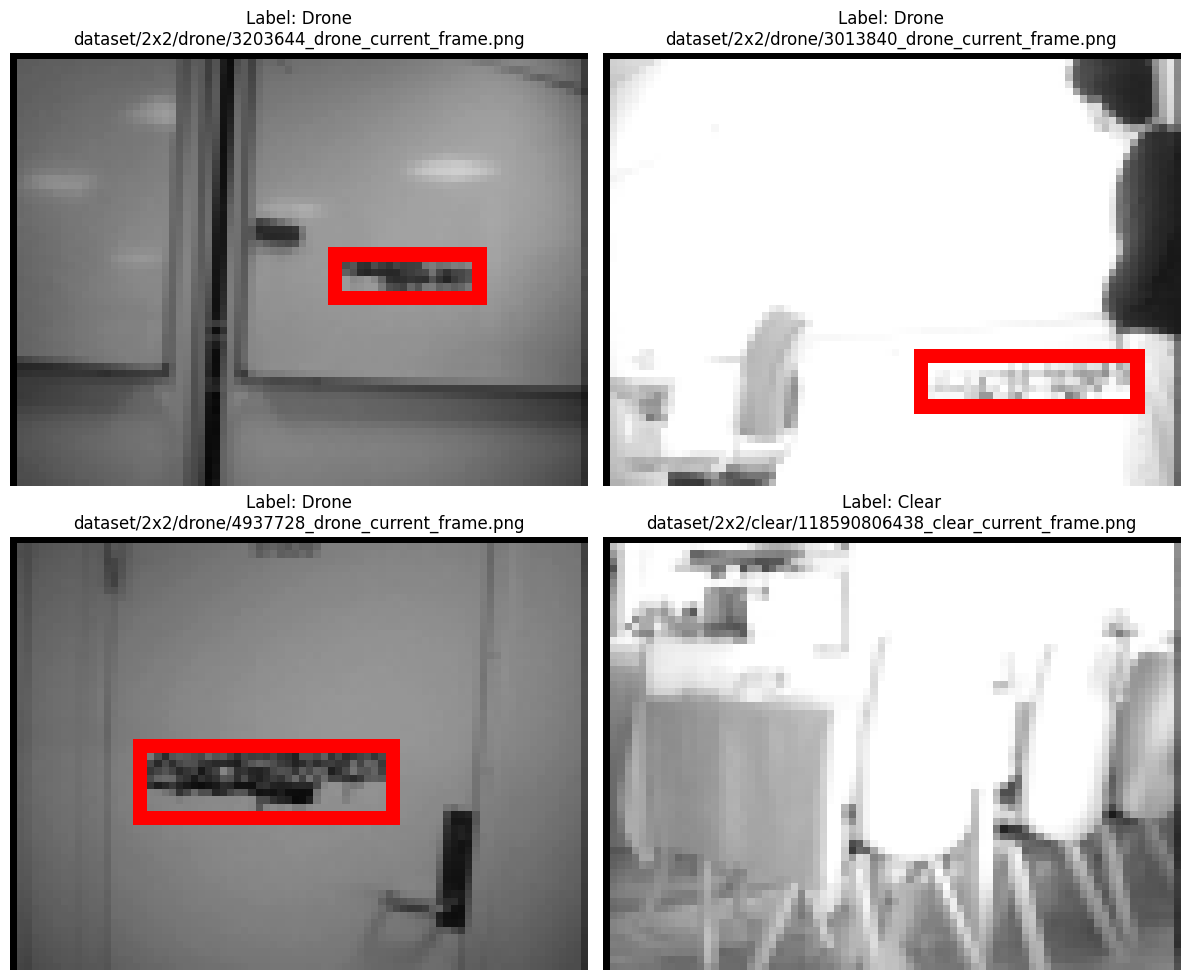

In [7]:
from PIL import Image, ImageDraw
import random
import matplotlib.pyplot as plt

def visualize_samples_with_bbox(X, y_combined, num_samples=4):
    plt.figure(figsize=(12, 10))
    # Show the first 'num_samples' images instead of random sampling
    sample_indices = range(min(num_samples, len(X)))

    for i, idx in enumerate(sample_indices):
        current_frame_path, _ = X[idx]
        label, bbox = y_combined[idx]

        # Load the current frame image
        img = Image.open(current_frame_path).convert('RGB')

        # If it's a drone, draw the bounding box
        if label == 1 and bbox and any(b > 0 for b in bbox): # Check if it's a drone and bbox data exists and is not [0,0,0,0]
            draw = ImageDraw.Draw(img)
            img_width, img_height = img.size

            # Convert normalized bbox to absolute coordinates
            # Bbox format: [x_center, y_center, box_width, box_height]
            x_center, y_center, box_width, box_height = bbox

            # Convert to (x_min, y_min, x_max, y_max)
            x_min = int((x_center - box_width / 2) * img_width)
            y_min = int((y_center - box_height / 2) * img_height)
            x_max = int((x_center + box_width / 2) * img_width)
            y_max = int((y_center + box_height / 2) * img_height)

            draw.rectangle([(x_min, y_min), (x_max, y_max)], outline='red', width=2)

        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {'Drone' if label == 1 else 'Clear'}\n{current_frame_path}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples_with_bbox(X, y_combined, num_samples=4)


### Verification of Augmented Data

Let's visualize a few samples from the augmented dataset (which now includes both original and flipped images) to ensure the horizontal flipping and bounding box adjustments are correct. The `visualize_samples_with_bbox` function will be used.

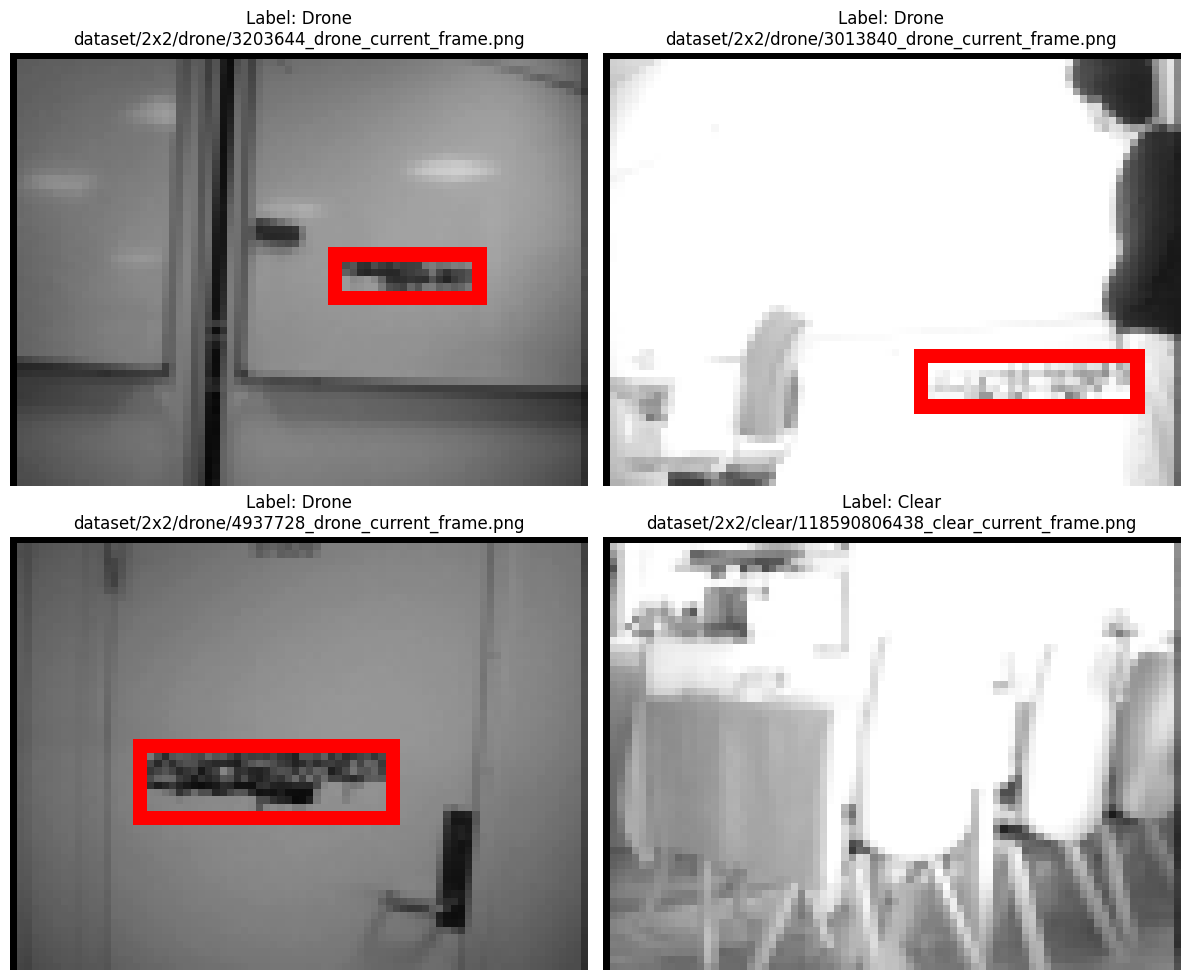

In [8]:
# Reuse the visualization function to show samples from the augmented dataset
# It will randomly pick 4 samples from the now doubled dataset.
visualize_samples_with_bbox(X, y_combined, num_samples=4)


Now that the image paths and labels are consolidated in `X` and `y`, the next step is to split them into training, validation, and testing sets. We will use `sklearn.model_selection.train_test_split` for this.

In [9]:
from sklearn.model_selection import train_test_split

# Combine X, y_classification, and y_bounding_box into a single list of tuples
# to ensure consistent splitting
combined_data_for_split = list(zip(X, y_classification, y_bounding_box))

# Split combined data into training and temporary sets (80% train, 20% temp)
# Stratify by classification label to maintain class distribution
train_data, temp_data = train_test_split(
    combined_data_for_split, test_size=0.2, random_state=42,
    stratify=y_classification
)

# Split temporary set into validation and test sets (50% validation, 50% test of the 20% temp)
# Stratify temp_data by its classification label (the second element in each tuple)
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42,
    stratify=[item[1] for item in temp_data]
)

# Unpack the split data
X_train, y_classification_train, y_bbox_train = zip(*train_data)
X_val, y_classification_val, y_bbox_val = zip(*val_data)
X_test, y_classification_test, y_bbox_test = zip(*test_data)

X_train = list(X_train)
y_classification_train = list(y_classification_train)
y_bbox_train = list(y_bbox_train)

X_val = list(X_val)
y_classification_val = list(y_classification_val)
y_bbox_val = list(y_bbox_val)

X_test = list(X_test)
y_classification_test = list(y_classification_test)
y_bbox_test = list(y_bbox_test)

print(f"Train set size: {len(X_train)} images")
print(f"Validation set size: {len(X_val)} images")
print(f"Test set size: {len(X_test)} images")

# Example prints for verification
print(f"First 5 X_train (image pairs): {X_train[:5]}")
print(f"First 5 y_classification_train (labels only): {y_classification_train[:5]}")
print(f"First 5 y_bbox_train (bboxes only): {y_bbox_train[:5]}")

Train set size: 11806 images
Validation set size: 1476 images
Test set size: 1476 images
First 5 X_train (image pairs): [('dataset/2x2/drone/14029865186_drone_current_frame.png', 'dataset/2x2/drone/14029865186_drone_diff_frame.png'), ('dataset_flipped/2x2/clear/49658_clear_current_frame.png', 'dataset_flipped/2x2/clear/49658_clear_diff_frame.png'), ('dataset_flipped/2x2/clear/14023245868_clear_current_frame.png', 'dataset_flipped/2x2/clear/14023245868_clear_diff_frame.png'), ('dataset_flipped/2x2/drone/1418556_drone_current_frame.png', 'dataset_flipped/2x2/drone/1418556_drone_diff_frame.png'), ('dataset_flipped/2x2/drone/679663_drone_current_frame.png', 'dataset_flipped/2x2/drone/679663_drone_diff_frame.png')]
First 5 y_classification_train (labels only): [1, 0, 0, 1, 1]
First 5 y_bbox_train (bboxes only): [[0.264062, 0.825667, 0.328125, 0.141667], [0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [0.629688, 0.39025, 0.371875, 0.2625], [0.8125, 0.148583, 0.3, 0.129167]]


In [10]:
import tensorflow as tf

# --- Configuration for image processing ---
# InputWidth and InputHeight are already defined globally
BATCH_SIZE = 32

# Function to preprocess a single image path
def preprocess_image(image_path):
    img = tf.io.read_file(image_path)
    # Decode PNG as grayscale (channels=1)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [InputHeight, InputWidth])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    return img

# Function to load and preprocess a paired data point
def load_and_preprocess_data(current_frame_path, diff_frame_path, label, bbox):
    current_frame_img = preprocess_image(current_frame_path)
    diff_frame_img = preprocess_image(diff_frame_path)

    # Ensure labels and bboxes are correctly typed for TensorFlow
    label = tf.cast(label, tf.float32) # For binary classification
    bbox = tf.cast(bbox, tf.float32)   # For regression

    # Model inputs: tuple of (current_frame_img, diff_frame_img)
    # Model outputs: tuple of (classification_label, bounding_box_coordinates)
    return (current_frame_img, diff_frame_img), (label, bbox)

Now, let's create `tf.data.Dataset` objects for the training, validation, and test sets using the split data and the preprocessing function.

In [11]:
# Helper function to create a dataset from split data
def create_dataset(X_data, y_classification_data, y_bbox_data, shuffle=True):
    current_frame_paths = [x[0] for x in X_data]
    diff_frame_paths = [x[1] for x in X_data]

    # Prepare y_true for bbox_output: combine classification label and bbox coordinates
    y_class_tensor = tf.expand_dims(tf.constant(y_classification_data, dtype=tf.float32), axis=-1) # Shape (num_samples, 1)
    y_bbox_tensor = tf.constant(y_bbox_data, dtype=tf.float32) # Shape (num_samples, 4)
    y_combined_for_bbox_output = tf.concat([y_class_tensor, y_bbox_tensor], axis=-1) # Shape (num_samples, 5)

    dataset = tf.data.Dataset.from_tensor_slices((
        current_frame_paths,
        diff_frame_paths,
        tf.constant(y_classification_data, dtype=tf.float32), # y_true for classification_output
        y_combined_for_bbox_output                            # y_true for bbox_output (label + bbox)
    ))

    dataset = dataset.map(load_and_preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X_data)) # Shuffle the entire dataset
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# Create datasets for training, validation, and testing
train_ds = create_dataset(X_train, y_classification_train, y_bbox_train)
val_ds = create_dataset(X_val, y_classification_val, y_bbox_val, shuffle=False) # No need to shuffle validation data
test_ds = create_dataset(X_test, y_classification_test, y_bbox_test, shuffle=False) # No need to shuffle test data

print(f"Created tf.data.Dataset objects for training, validation, and testing with batch size {BATCH_SIZE}.")

print("\nExample of one batch structure from train_ds:")
for (curr_img, diff_img), (label_batch, bbox_batch) in train_ds.take(1):
    print(f"  Current Frame Image Batch Shape: {curr_img.shape} (expected: {BATCH_SIZE}, {InputHeight}, {InputWidth}, 1)")
    print(f"  Diff Frame Image Batch Shape: {diff_img.shape} (expected: {BATCH_SIZE}, {InputHeight}, {InputWidth}, 1)")
    print(f"  Classification Label Batch Shape: {label_batch.shape} (expected: {BATCH_SIZE},)")
    # The bbox_batch here will now have 5 elements per sample (label + 4 bbox coords)
    print(f"  Bounding Box Batch Shape: {bbox_batch.shape} (expected: {BATCH_SIZE}, 5)")
    break

Created tf.data.Dataset objects for training, validation, and testing with batch size 32.

Example of one batch structure from train_ds:
  Current Frame Image Batch Shape: (32, 60, 80, 1) (expected: 32, 60, 80, 1)
  Diff Frame Image Batch Shape: (32, 60, 80, 1) (expected: 32, 60, 80, 1)
  Classification Label Batch Shape: (32,) (expected: 32,)
  Bounding Box Batch Shape: (32, 5) (expected: 32, 5)


In [12]:
import tf_keras.backend as K
import tensorflow as tf

def bbox_to_coords(bbox):
    """Converts (x_center, y_center, width, height) to (x1, y1, x2, y2)."""
    x_center, y_center, width, height = tf.unstack(bbox, axis=-1)
    x1 = x_center - width / 2
    y1 = y_center - height / 2
    x2 = x_center + width / 2
    y2 = y_center + height / 2
    return x1, y1, x2, y2

def giou_loss(y_true, y_pred):
    """
    Calculates the Generalized IoU (GIoU) loss.
    y_true: (batch_size, 4) with (x_center, y_center, width, height)
    y_pred: (batch_size, 4) with (x_center, y_center, width, height)
    """
    # Convert from (x_center, y_center, width, height) to (x1, y1, x2, y2)
    gt_x1, gt_y1, gt_x2, gt_y2 = bbox_to_coords(y_true)
    pred_x1, pred_y1, pred_x2, pred_y2 = bbox_to_coords(y_pred)

    # Calculate intersection area
    inter_x1 = K.maximum(gt_x1, pred_x1)
    inter_y1 = K.maximum(gt_y1, pred_y1)
    inter_x2 = K.minimum(gt_x2, pred_x2)
    inter_y2 = K.minimum(gt_y2, pred_y2)

    inter_width = K.maximum(0.0, inter_x2 - inter_x1)
    inter_height = K.maximum(0.0, inter_y2 - inter_y1)
    inter_area = inter_width * inter_height

    # Calculate union area
    gt_area = (gt_x2 - gt_x1) * (gt_y2 - gt_y1)
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
    union_area = gt_area + pred_area - inter_area

    # Avoid division by zero
    union_area = K.maximum(K.epsilon(), union_area)

    # Calculate IoU
    iou = inter_area / union_area

    # Calculate smallest enclosing box (C) coordinates
    encl_x1 = K.minimum(gt_x1, pred_x1)
    encl_y1 = K.minimum(gt_y1, pred_y1)
    encl_x2 = K.maximum(gt_x2, pred_x2)
    encl_y2 = K.maximum(gt_y2, pred_y2)

    encl_width = K.maximum(0.0, encl_x2 - encl_x1)
    encl_height = K.maximum(0.0, encl_y2 - encl_y1)
    encl_area = encl_width * encl_height

    # Avoid division by zero for enclosing area
    encl_area = K.maximum(K.epsilon(), encl_area)

    # Calculate GIoU
    giou = iou - (encl_area - union_area) / encl_area

    # GIoU Loss is 1 - GIoU
    loss = 1.0 - giou
    return loss

def masked_giou_loss(y_true_combined, y_pred_bbox):
    # y_true_combined has shape (batch_size, 5) where:
    # y_true_combined[:, 0] is the classification label (0 or 1)
    # y_true_combined[:, 1:] are the true bounding box coordinates (x, y, w, h)

    true_labels = y_true_combined[:, 0]
    true_bboxes = y_true_combined[:, 1:]

    # Calculate GIoU loss for all samples
    giou_batch_loss = giou_loss(true_bboxes, y_pred_bbox)

    # Apply the mask: only apply loss if true_labels == 1 (drone present)
    masked_loss = tf.where(tf.equal(true_labels, 1.0), giou_batch_loss, 0.0)

    # Return the mean of the masked loss for the batch
    return K.mean(masked_loss)

def create_model():
    image1_input = layers.Input(shape=(InputHeight, InputWidth, 1), name='image1_input')
    image2_input = layers.Input(shape=(InputHeight, InputWidth, 1), name='image2_input')

    # Now, pass this combined input through a single feature extraction branch
    def feature_extractor_branch(x):
        x = layers.Conv2D(24, (3,3), strides=2, padding='same')(x)
        x = layers.ReLU()(x)

        x = layers.Conv2D(8, (3,3), strides=2, padding='same')(x)
        x = layers.ReLU()(x)
        return x

    # Get features from the combined input
    common_feature1 = feature_extractor_branch(image1_input)
    common_feature2 = feature_extractor_branch(image2_input)

    pooled_features1 = layers.GlobalAveragePooling2D()(common_feature1)
    pooled_features2 = layers.GlobalAveragePooling2D()(common_feature2)

    # Concatenate the features
    combined_pooled_features = layers.Concatenate()([pooled_features1, pooled_features2])

    # Classification Branch
    combined_features = layers.Concatenate()([common_feature1, common_feature2])

    # --- Classification Branch ---
    # 'combined_pooled_features' is already the result of GlobalAveragePooling2D and concatenation,
    # so it's already 2D. It should be passed directly to the Dense layers.
    classification_branch = layers.Dense(64, activation="relu")(combined_pooled_features)
    classification_branch = layers.Dense(32, activation="relu")(classification_branch)
    classification_branch = layers.Dense(16, activation="relu")(classification_branch)
    classification_output = layers.Dense(1, activation="sigmoid", name='classification_output')(classification_branch)

    # --- Bounding Box Regression Branch ---
    # Flatten the combined spatial features for bounding box prediction
    flattened_bbox_features = layers.Flatten()(combined_features)
    bbox_branch = layers.Dense(16, activation="relu")(flattened_bbox_features)
    bbox_branch = layers.Dense(8, activation="relu")(bbox_branch)
    bbox_output = layers.Dense(4, activation="sigmoid", name='bbox_output')(bbox_branch)

    model = keras.Model(inputs=[image1_input, image2_input], outputs=[classification_output, bbox_output])

    # Compile the model with separate losses and metrics for each output
    model.compile(
        loss={'classification_output': 'binary_crossentropy', 'bbox_output': masked_giou_loss},
        optimizer="adam",
        metrics={
            'classification_output': ['accuracy']
            # Removed 'mean_squared_error' for bbox_output as it conflicts with the 5-element target
        },
    )
    return model

model = create_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 image1_input (InputLayer)   [(None, 60, 80, 1)]          0         []                            
                                                                                                  
 image2_input (InputLayer)   [(None, 60, 80, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 30, 40, 24)           240       ['image1_input[0][0]']        
                                                                                                  
 conv2d_2 (Conv2D)           (None, 30, 40, 24)           240       ['image2_input[0][0]']        
                                                                                              

# Train and Save Model

In [13]:
history = model.fit(
    x=train_ds,
    epochs=64,
    validation_data=val_ds,
    verbose=1,
)

scores = model.evaluate(test_ds, verbose=2)
print("Test Loss:    ", scores[0])
print("Test Accuracy:", scores[1]) # This will be the accuracy for the first output (classification)

# If you need to access individual metrics for multi-output models:
# For classification accuracy:
print(f"Test Classification Loss: {scores[1]:.4f}")
print(f"Test Classification Accuracy: {scores[3]:.4f}")
# For bounding box MSE:
print(f"Test Bounding Box Loss (MSE): {scores[2]:.4f}")

model.save("drone_detection_model.keras")

Epoch 1/64
369/369 [==============================] - 30s 60ms/step - loss: 1.1291 - classification_output_loss: 0.6810 - bbox_output_loss: 0.4481 - classification_output_accuracy: 0.5631 - val_loss: 1.0606 - val_classification_output_loss: 0.6381 - val_bbox_output_loss: 0.4225 - val_classification_output_accuracy: 0.6436
Epoch 2/64
369/369 [==============================] - 22s 51ms/step - loss: 1.0492 - classification_output_loss: 0.6384 - bbox_output_loss: 0.4108 - classification_output_accuracy: 0.6438 - val_loss: 1.0315 - val_classification_output_loss: 0.6270 - val_bbox_output_loss: 0.4045 - val_classification_output_accuracy: 0.6538
Epoch 3/64
369/369 [==============================] - 25s 53ms/step - loss: 1.0034 - classification_output_loss: 0.6143 - bbox_output_loss: 0.3891 - classification_output_accuracy: 0.6664 - val_loss: 0.9651 - val_classification_output_loss: 0.5811 - val_bbox_output_loss: 0.3840 - val_classification_output_accuracy: 0.6829
Epoch 4/64
369/369 [========

## Training and Validation Loss

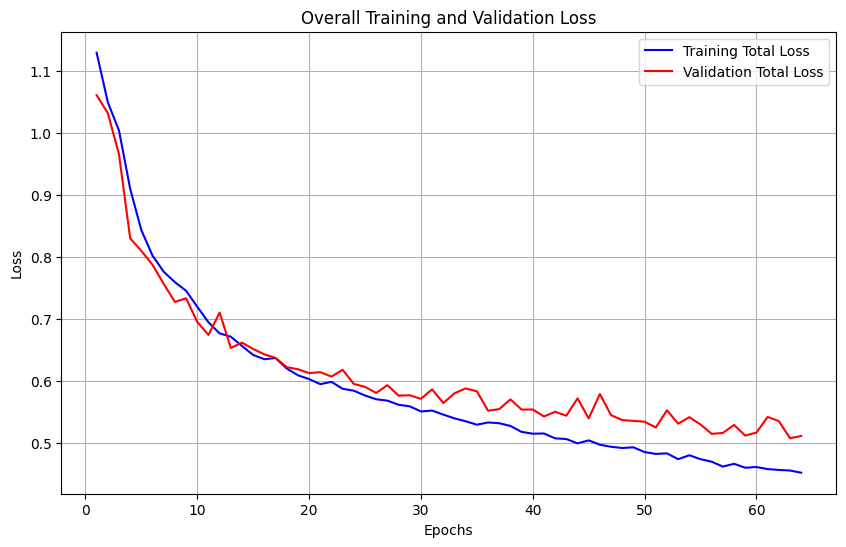

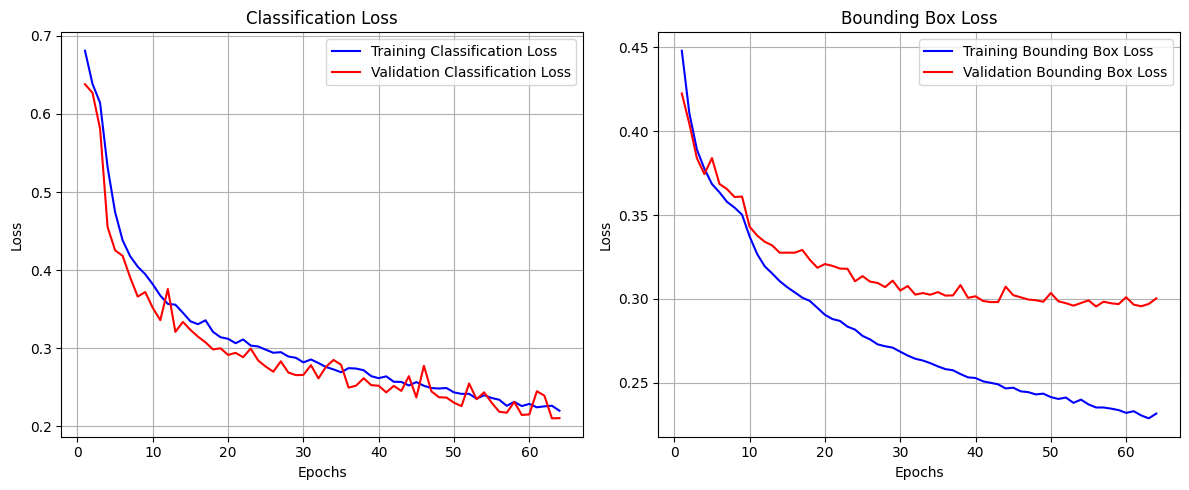

In [14]:
import matplotlib.pyplot as plt

# Extract loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_class_loss = history.history['classification_output_loss']
val_class_loss = history.history['val_classification_output_loss']
train_bbox_loss = history.history['bbox_output_loss']
val_bbox_loss = history.history['val_bbox_output_loss']
epochs = range(1, len(train_loss) + 1)

# Figure 1: Overall Training and Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Total Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Total Loss')
plt.title('Overall Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Figure 2: Classification and Bounding Box Losses
plt.figure(figsize=(12, 5))

# Subplot 1: Classification Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, train_class_loss, 'b', label='Training Classification Loss')
plt.plot(epochs, val_class_loss, 'r', label='Validation Classification Loss')
plt.title('Classification Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Bounding Box Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, train_bbox_loss, 'b', label='Training Bounding Box Loss')
plt.plot(epochs, val_bbox_loss, 'r', label='Validation Bounding Box Loss')
plt.title('Bounding Box Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Evaluate Model Predictions on a Sample

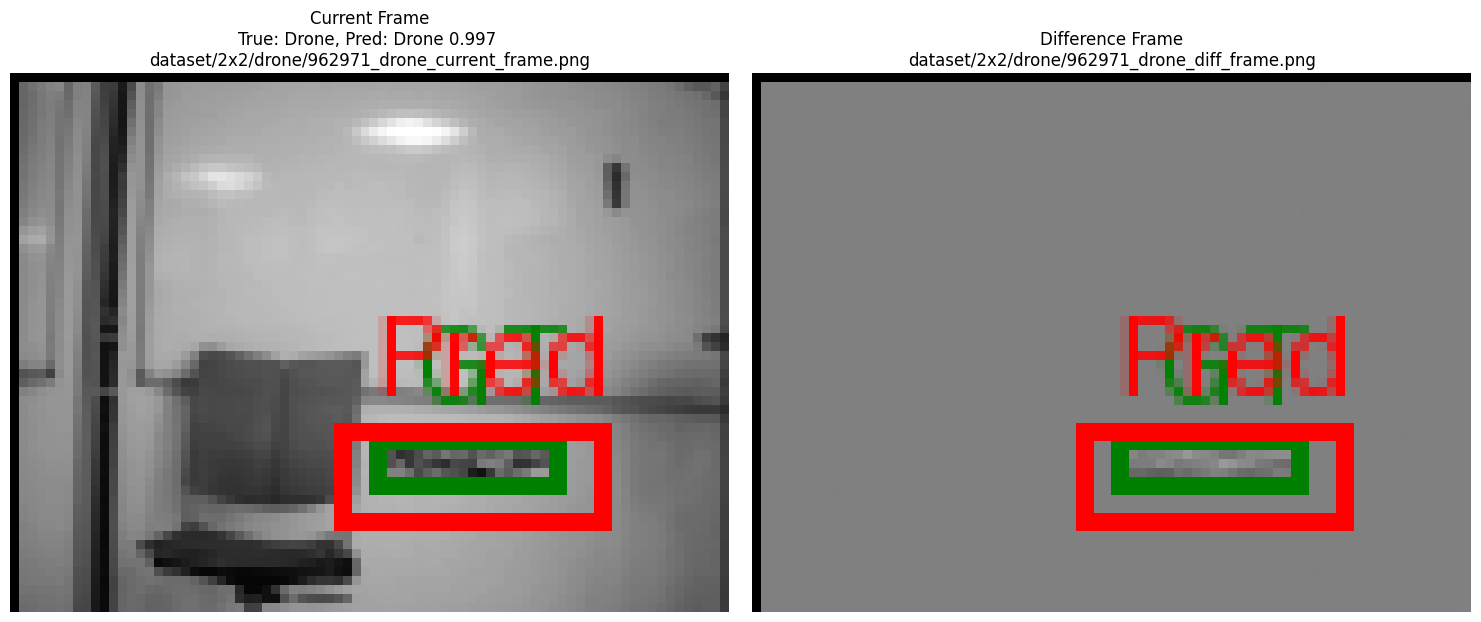

In [121]:
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

def visualize_single_prediction_with_bboxes(model, X_sample, y_class_sample, y_bbox_sample, InputHeight, InputWidth):
    current_frame_path, diff_frame_path = X_sample
    true_label = y_class_sample
    true_bbox_coords = y_bbox_sample

    # Preprocess the sample images
    current_frame_img_processed = preprocess_image(current_frame_path)
    diff_frame_img_processed = preprocess_image(diff_frame_path)

    # Add batch dimension for model prediction
    current_frame_input = tf.expand_dims(current_frame_img_processed, axis=0)
    diff_frame_input = tf.expand_dims(diff_frame_img_processed, axis=0)

    # Get model prediction
    pred_class, pred_bbox = model.predict([current_frame_input, diff_frame_input], verbose=0)

    # Process predicted classification
    predicted_label = 1 if pred_class[0][0] > 0.5 else 0
    predicted_bbox_coords = pred_bbox[0]

    # Load images for visualization
    img_current = Image.open(current_frame_path).convert('RGB')
    img_diff = Image.open(diff_frame_path).convert('RGB')

    img_width, img_height = img_current.size
    draw_current = ImageDraw.Draw(img_current)
    draw_diff = ImageDraw.Draw(img_diff) # Create draw object for diff frame

    # Helper function to draw a bounding box
    def draw_bbox(draw_obj, bbox_coords, color, label_text):
        if any(b > 0 for b in bbox_coords): # Fixed: Removed 'bbox_coords and' check
            x_center, y_center, box_width, box_height = bbox_coords
            x_min = int((x_center - box_width / 2) * img_width)
            y_min = int((y_center - box_height / 2) * img_height)
            x_max = int((x_center + box_width / 2) * img_width)
            y_max = int((y_center + box_height / 2) * img_height)
            draw_obj.rectangle([(x_min, y_min), (x_max, y_max)], outline=color, width=2)
            # Use a default font size or try to infer one if 'font_size' is not directly supported in ImageDraw.text
            # For simplicity, we'll use a fixed position for text for now, or you might need a font object.
            try:
                draw_obj.text((x_min + 5, y_min - 15), label_text, fill=color, font_size=12)
            except TypeError: # Older PIL versions might not have font_size in text function
                draw_obj.text((x_min + 5, y_min - 15), label_text, fill=color) # Fallback without font_size

    # Draw Ground Truth Bounding Box on current and diff frames (if drone present)
    if true_label == 1:
        draw_bbox(draw_current, true_bbox_coords, 'green', "GT")
        draw_bbox(draw_diff, true_bbox_coords, 'green', "GT") # Draw on diff frame as well

    # Draw Predicted Bounding Box on current and diff frames (if predicted as drone)
    if predicted_label == 1:
        draw_bbox(draw_current, predicted_bbox_coords, 'red', "Pred")
        draw_bbox(draw_diff, predicted_bbox_coords, 'red', "Pred") # Draw on diff frame as well

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_current)
    plt.title(f"Current Frame\nTrue: {'Drone' if true_label == 1 else 'Clear'}, Pred: {'Drone' if predicted_label == 1 else 'Clear'} {pred_class[0][0]:.3f} \n{current_frame_path}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_diff)
    plt.title(f"Difference Frame\n{diff_frame_path}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Select a random sample from the test set for visualization
random_index = random.randint(0, len(X_test) - 1)
X_sample = X_test[random_index]
y_class_sample = y_classification_test[random_index]
y_bbox_sample = y_bbox_test[random_index]

# Visualize the prediction for the selected sample
visualize_single_prediction_with_bboxes(model, X_sample, y_class_sample, y_bbox_sample, InputHeight, InputWidth)


## Confusion Matrix for Classification

47/47 [==============================] - 1s 22ms/step


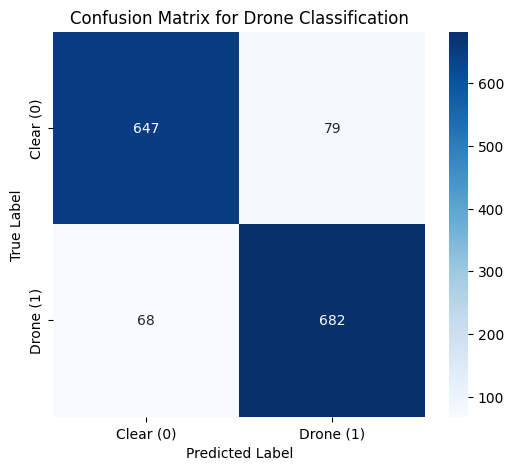

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions for the test dataset
y_pred_classification_raw, _ = model.predict(test_ds)

# Convert probabilities to binary predictions (0 or 1)
y_pred_classification = (y_pred_classification_raw > 0.5).astype(int)

# 2. Get true labels for the test dataset
y_true_classification = []
for (_, _), (label_batch, _) in test_ds.unbatch():
    y_true_classification.append(int(label_batch.numpy()))
y_true_classification = np.array(y_true_classification)

# Ensure both true and predicted labels have the same number of samples
# (Sometimes prediction can have slightly fewer due to batching issues if dataset size isn't a multiple of batch_size)
min_samples = min(len(y_true_classification), len(y_pred_classification))
y_true_classification = y_true_classification[:min_samples]
y_pred_classification = y_pred_classification[:min_samples]

# 3. Compute the confusion matrix
cm = confusion_matrix(y_true_classification, y_pred_classification)

# 4. Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Clear (0)', 'Drone (1)'],
            yticklabels=['Clear (0)', 'Drone (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Drone Classification')
plt.show()

# Full INT8 Post-Training Quantization (PTQ)

In [123]:
NUM_PTQ_SAMPLES = 100
ptq_samples_X = X_train[:NUM_PTQ_SAMPLES]

def representative_dataset_gen():
    for i in range(len(ptq_samples_X)):
        current_frame_path, diff_frame_path = ptq_samples_X[i]

        # Preprocess images using the existing function
        current_frame_img = preprocess_image(current_frame_path) # tf.Tensor (H, W, 1) float32
        diff_frame_img = preprocess_image(diff_frame_path)       # tf.Tensor (H, W, 1) float32

        # TFLite converter expects a list of numpy arrays for each input
        yield [
            tf.expand_dims(current_frame_img, axis=0).numpy().astype(np.float32), # (1, H, W, 1) float32
            tf.expand_dims(diff_frame_img, axis=0).numpy().astype(np.float32)     # (1, H, W, 1) float32
        ]

converter_ptq = tf.lite.TFLiteConverter.from_keras_model(model)
converter_ptq.optimizations = [tf.lite.Optimize.DEFAULT]
converter_ptq.representative_dataset = representative_dataset_gen
converter_ptq.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_ptq.inference_input_type  = tf.int8
converter_ptq.inference_output_type = tf.int8

tflite_ptq = converter_ptq.convert()
open("drone_model_ptq_int8.tflite", "wb").write(tflite_ptq)
print("PTQ INT8 model saved — size:", len(tflite_ptq), "bytes")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


PTQ INT8 model saved — size: 97944 bytes


# Quantization-Aware Training (QAT)

In [124]:
# # 1. Wrap the trained model with QAT fake-quantization
# # Note: tfmot.quantization.keras.quantize_model() requires a Functional model.
# functional_model = keras.Model(inputs=model.input, outputs=model.output)
# q_aware_model = tfmot.quantization.keras.quantize_model(functional_model)

# q_aware_model.compile(
#     loss="sparse_categorical_crossentropy",
#     optimizer="adam",
#     metrics=["accuracy"],
# )
# q_aware_model.summary()

In [125]:
# # 2. Fine-tune for 5 epochs
# q_aware_model.fit(
#     x=x_train,
#     y=y_train,
#     batch_size=128,
#     epochs=5,
#     validation_split=0.1,
#     verbose=1,
# )

In [126]:
# # 3. Convert the QAT model to INT8 TFLite
# converter_qat = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
# converter_qat.optimizations = [tf.lite.Optimize.DEFAULT]
# converter_qat.representative_dataset = representative_dataset
# converter_qat.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# converter_qat.inference_input_type  = tf.int8
# converter_qat.inference_output_type = tf.int8

# tflite_qat = converter_qat.convert()
# open("model_qat_int8.tflite", "wb").write(tflite_qat)
# print("QAT INT8 model saved — size:", len(tflite_qat), "bytes")

# Model Size Comparison

INT8 models store weights as 8-bit integers instead of 32-bit floats — roughly **4× smaller**. On a microcontroller with only tens of kilobytes of flash, this difference matters enormously.

In [127]:
# Save the float model as TFLite for a fair comparison
converter_float = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_float = converter_float.convert()
open("model_float32.tflite", "wb").write(tflite_float)

sizes = {
    "Float32 TFLite": os.path.getsize("model_float32.tflite"),
    "PTQ INT8      ": os.path.getsize("drone_model_ptq_int8.tflite"),
}

print(f"{'Model':<20} {'Size (bytes)':>14} {'Size (KB)':>10}")
print("-" * 46)
for name, size in sizes.items():
    print(f"{name:<20} {size:>14,} {size/1024:>9.1f}")

Model                  Size (bytes)  Size (KB)
----------------------------------------------
Float32 TFLite              345,224     337.1
PTQ INT8                     97,944      95.6


# Test TFLite Models

Test **sample-by-sample** — exactly how inference runs on a microcontroller. For INT8 models the input must be scaled from `float32` to `int8` using the quantization parameters reported by the interpreter.

In [128]:
def evaluate_tflite(model_path, X_data, y_classification_true, max_samples=None):
    """Run TFLite inference sample-by-sample and return classification accuracy."""
    interpreter = litert.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Assuming two inputs and two outputs based on the model structure
    # Input 0: current_frame_img, Input 1: diff_frame_img
    # Output 0: classification_output, Output 1: bbox_output

    input_dtype_curr = input_details[0]["dtype"]
    input_dtype_diff = input_details[1]["dtype"]

    is_int8_curr = (input_dtype_curr == np.int8)
    is_int8_diff = (input_dtype_diff == np.int8)

    if is_int8_curr:
        scale_curr, zero_point_curr = input_details[0]["quantization"]
    if is_int8_diff:
        scale_diff, zero_point_diff = input_details[1]["quantization"]

    correct_classification = 0
    num_samples = len(X_data)
    if max_samples is not None:
        num_samples = min(num_samples, max_samples)

    for i in range(num_samples):
        current_frame_path, diff_frame_path = X_data[i]

        # Preprocess images using the existing function
        current_frame_img = preprocess_image(current_frame_path) # tf.Tensor (H, W, 1) float32
        diff_frame_img = preprocess_image(diff_frame_path)       # tf.Tensor (H, W, 1) float32

        # Add batch dimension and convert to numpy
        current_frame_sample = tf.expand_dims(current_frame_img, axis=0).numpy() # (1, H, W, 1) float32
        diff_frame_sample = tf.expand_dims(diff_frame_img, axis=0).numpy()       # (1, H, W, 1) float32

        # Quantize inputs if necessary
        if is_int8_curr:
            current_frame_sample = (current_frame_sample / scale_curr + zero_point_curr).astype(np.int8)
        if is_int8_diff:
            diff_frame_sample = (diff_frame_sample / scale_diff + zero_point_diff).astype(np.int8)

        # Set inputs
        interpreter.set_tensor(input_details[0]["index"], current_frame_sample)
        interpreter.set_tensor(input_details[1]["index"], diff_frame_sample)
        interpreter.invoke()

        # Get outputs
        classification_output = interpreter.get_tensor(output_details[0]["index"])
        # bbox_output = interpreter.get_tensor(output_details[1]["index"]) # Not used for classification accuracy

        # Dequantize classification output if it is int8
        if output_details[0]["dtype"] == np.int8:
            output_scale_class, output_zero_point_class = output_details[0]["quantization"]
            classification_output = (classification_output.astype(np.float32) - output_zero_point_class) * output_scale_class

        # For classification, convert probability to binary prediction
        pred_class = 1 if classification_output[0][0] > 0.5 else 0

        if pred_class == y_classification_true[i]:
            correct_classification += 1

    accuracy = correct_classification / num_samples
    return accuracy

def evaluate_keras_model(keras_model, X_data, y_classification_true, max_samples=None):
    """Run Keras model inference and return classification accuracy."""
    num_samples = len(X_data)
    if max_samples is not None:
        num_samples = min(num_samples, max_samples)

    # Prepare data for prediction
    current_frame_inputs = []
    diff_frame_inputs = []
    for i in range(num_samples):
        current_frame_path, diff_frame_path = X_data[i]
        current_frame_inputs.append(preprocess_image(current_frame_path))
        diff_frame_inputs.append(preprocess_image(diff_frame_path))

    current_frame_inputs = tf.stack(current_frame_inputs)
    diff_frame_inputs = tf.stack(diff_frame_inputs)

    # Get predictions
    pred_class_raw, _ = keras_model.predict([current_frame_inputs, diff_frame_inputs], verbose=0)
    pred_class = (pred_class_raw > 0.5).astype(int).flatten()

    correct_classification = np.sum(pred_class == np.array(y_classification_true[:num_samples]))
    accuracy = correct_classification / num_samples
    return accuracy

# Evaluate the original Keras model
acc_keras = evaluate_keras_model(model, X_test, y_classification_test, max_samples=1000)
print(f"Original Keras model classification accuracy (sample) : {acc_keras:.4f}")

# Evaluate the float32 TFLite model
acc_float_tflite = evaluate_tflite("model_float32.tflite", X_test, y_classification_test, max_samples=1000)
print(f"Float32 TFLite classification accuracy (sample) : {acc_float_tflite:.4f}")


# Evaluate the PTQ INT8 TFLite model
acc_ptq_tflite = evaluate_tflite("drone_model_ptq_int8.tflite", X_test, y_classification_test, max_samples=1000)
print(f"PTQ INT8 TFLite classification accuracy (sample) : {acc_ptq_tflite:.4f}")


Original Keras model classification accuracy (sample) : 0.9060
Float32 TFLite classification accuracy (sample) : 0.9060
PTQ INT8 TFLite classification accuracy (sample) : 0.9100


# Export as C Arrays

The `.tflite` binary is embedded in a C header as a `const` byte array. The MCU firmware reads this array directly from flash.

Good practices for MCU C headers:
- `#ifndef` / `#define` / `#endif` — prevent double-inclusion
- `alignas(16)` — ensures 16-byte alignment for SIMD-like hardware (e.g. DSP cores)
- `const` — allows the linker to place the array in read-only flash

In [131]:
import binascii
import datetime

def to_c_array(data: bytes) -> str:
    """Convert bytes to a comma-separated C hex array, 12 bytes per line."""
    hexstr = binascii.hexlify(data).decode("ascii").upper()
    values = ["0x" + hexstr[i:i+2] for i in range(0, len(hexstr), 2)]
    lines  = [", ".join(values[i:i+12]) for i in range(0, len(values), 12)]
    return ",\n  ".join(lines)

def write_c_header(tflite_path: str, header_path: str, array_name: str, quant_type: str):
    data = open(tflite_path, "rb").read()
    guard = array_name.upper() + "_H"
    body = (
        f"// Auto-generated on {datetime.date.today()}\n"
        f"// Model: {tflite_path}  |  Quantization: {quant_type}  |  Size: {len(data)} bytes\n"
        f"#ifndef {guard}\n"
        f"#define {guard}\n"
        f"#include <stdint.h>\n"
        f"#include <stdalign.h>\n\n"
        f"alignas(16) const uint8_t {array_name}[] = {{\n  "
        + to_c_array(data) +
        f"\n}};\n"
        f"const unsigned int {array_name}_len = {len(data)};\n\n"
        f"#endif  // {guard}\n"
    )
    open(header_path, "w").write(body)
    print(f"Written {header_path}  ({len(data)} bytes)")

write_c_header("drone_model_ptq_int8.tflite", "drone_model_ptq_int8.h", "tf_drone_model_ptq", "INT8 PTQ")
# write_c_header("model_qat_int8.tflite", "model_qat_int8.h", "tf_model_qat", "INT8 QAT")

Written drone_model_ptq_int8.h  (97944 bytes)


## Test TFLite Model Predictions on a Sample

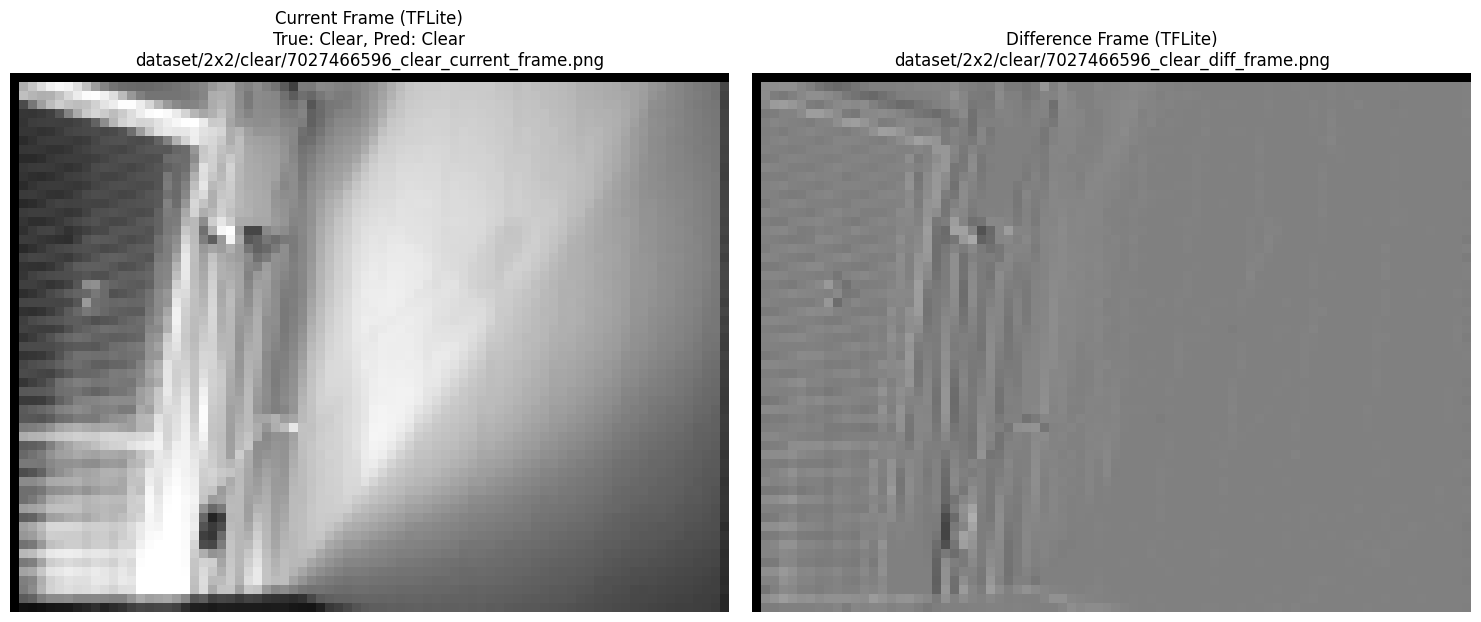

In [130]:
def visualize_tflite_prediction_with_bboxes(tflite_model_path, X_sample, y_class_sample, y_bbox_sample, InputHeight, InputWidth):
    current_frame_path, diff_frame_path = X_sample
    true_label = y_class_sample
    true_bbox_coords = y_bbox_sample

    # Initialize TFLite Interpreter
    interpreter = litert.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Get input tensor details for quantization
    input_dtype_curr = input_details[0]["dtype"]
    input_dtype_diff = input_details[1]["dtype"]

    is_int8_curr = (input_dtype_curr == np.int8)
    is_int8_diff = (input_dtype_diff == np.int8)

    if is_int8_curr:
        scale_curr, zero_point_curr = input_details[0]["quantization"]
    if is_int8_diff:
        scale_diff, zero_point_diff = input_details[1]["quantization"]

    # Preprocess the sample images
    current_frame_img_processed = preprocess_image(current_frame_path) # tf.Tensor (H, W, 1) float32
    diff_frame_img_processed = preprocess_image(diff_frame_path)       # tf.Tensor (H, W, 1) float32

    # Add batch dimension and convert to numpy
    current_frame_sample = tf.expand_dims(current_frame_img_processed, axis=0).numpy() # (1, H, W, 1) float32
    diff_frame_sample = tf.expand_dims(diff_frame_img_processed, axis=0).numpy()       # (1, H, W, 1) float32

    # Quantize inputs if necessary
    if is_int8_curr:
        current_frame_sample = (current_frame_sample / scale_curr + zero_point_curr).astype(np.int8)
    if is_int8_diff:
        diff_frame_sample = (diff_frame_sample / scale_diff + zero_point_diff).astype(np.int8)

    # Set inputs
    interpreter.set_tensor(input_details[0]["index"], current_frame_sample)
    interpreter.set_tensor(input_details[1]["index"], diff_frame_sample)
    interpreter.invoke()

    # Get outputs
    classification_output = interpreter.get_tensor(output_details[0]["index"])
    bbox_output = interpreter.get_tensor(output_details[1]["index"])

    # Dequantize classification output if it is int8
    if output_details[0]["dtype"] == np.int8:
        output_scale_class, output_zero_point_class = output_details[0]["quantization"]
        classification_output = (classification_output.astype(np.float32) - output_zero_point_class) * output_scale_class

    # Dequantize bounding box output if it is int8 (assuming it will also be int8 for quantized models)
    if output_details[1]["dtype"] == np.int8:
        output_scale_bbox, output_zero_point_bbox = output_details[1]["quantization"]
        bbox_output = (bbox_output.astype(np.float32) - output_zero_point_bbox) * output_scale_bbox

    # Process predicted classification
    predicted_label = 1 if classification_output[0][0] > 0.5 else 0
    predicted_bbox_coords = bbox_output[0] # Assuming bbox_output is already normalized [0,1]

    # Load images for visualization
    img_current = Image.open(current_frame_path).convert('RGB')
    img_diff = Image.open(diff_frame_path).convert('RGB')

    img_width, img_height = img_current.size
    draw_current = ImageDraw.Draw(img_current)
    draw_diff = ImageDraw.Draw(img_diff) # Create draw object for diff frame

    # Helper function to draw a bounding box
    def draw_bbox(draw_obj, bbox_coords, color, label_text):
        # Ensure bbox_coords is a list/tuple of 4 floats
        if bbox_coords is not None and len(bbox_coords) == 4 and any(b > 0 for b in bbox_coords):
            x_center, y_center, box_width, box_height = bbox_coords
            x_min = int((x_center - box_width / 2) * img_width)
            y_min = int((y_center - box_height / 2) * img_height)
            x_max = int((x_center + box_width / 2) * img_width)
            y_max = int((y_center + box_height / 2) * img_height)
            draw_obj.rectangle([(x_min, y_min), (x_max, y_max)], outline=color, width=2)
            try:
                draw_obj.text((x_min + 5, y_min - 15), label_text, fill=color, font_size=12)
            except TypeError:
                draw_obj.text((x_min + 5, y_min - 15), label_text, fill=color)

    # Draw Ground Truth Bounding Box on current and diff frames (if drone present)
    if true_label == 1:
        draw_bbox(draw_current, true_bbox_coords, 'green', "GT")
        draw_bbox(draw_diff, true_bbox_coords, 'green', "GT") # Draw on diff frame as well

    # Draw Predicted Bounding Box on current and diff frames (if predicted as drone)
    if predicted_label == 1:
        draw_bbox(draw_current, predicted_bbox_coords, 'red', "Pred")
        draw_bbox(draw_diff, predicted_bbox_coords, 'red', "Pred") # Draw on diff frame as well

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_current)
    plt.title(f"Current Frame (TFLite)\nTrue: {'Drone' if true_label == 1 else 'Clear'}, Pred: {'Drone' if predicted_label == 1 else 'Clear'}\n{current_frame_path}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_diff)
    plt.title(f"Difference Frame (TFLite)\n{diff_frame_path}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Select a random sample from the test set for visualization
random_index = random.randint(0, len(X_test) - 1)
X_sample_tflite = X_test[random_index]
y_class_sample_tflite = y_classification_test[random_index]
y_bbox_sample_tflite = y_bbox_test[random_index]

# Visualize the prediction for the selected sample using the PTQ INT8 TFLite model
visualize_tflite_prediction_with_bboxes(
    "drone_model_ptq_int8.tflite",
    X_sample_tflite,
    y_class_sample_tflite,
    y_bbox_sample_tflite,
    InputHeight,
    InputWidth
)